Proyecto Valuación Opciones

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as si
import matplotlib.pyplot as plt

Modelo Black Scholes

In [120]:
import numpy as np
import scipy.stats as si
#Scipy funciona para obtener la acumulada de la distribución Normal.
#Spot = Precio Spot del activo subyacente hoy
# K = Precio strike de la opción
# option_type = será el parámetro que defina si la opción es de compra o venta (call o put)
#sigma = representa la volatilidad del precio del activo subyacente
#r = la tasa libre de riesgo que se usará para el cálculo.

def black_scholes(Spot, K, mat, r, sigma):

    Spot = np.asarray(Spot)
    K = np.asarray(K)
    mat = np.asarray(mat)
    sigma = np.asarray(sigma)
    r = np.asarray(r)

    # =========================
    # VALIDACIONES
    # =========================
    if np.any(Spot <= 0):
        raise ValueError("El precio spot debe ser positivo")
    if np.any(K <= 0):
        raise ValueError("Strike debe ser positivo")
    if np.any(mat < 0):
        raise ValueError("El tiempo debe ser >= 0")
    if np.any(sigma < 0):
        raise ValueError("La volatilidad no puede ser negativa")

    # =========================
    # CASO T = 0
    # =========================
    call_intrinsic = np.maximum(Spot - K, 0)
    put_intrinsic = np.maximum(K - Spot, 0)

    if np.all(mat == 0):
        return {"call": call_intrinsic, "put": put_intrinsic}

    # =========================
    # CASO sigma = 0
    # =========================
    if np.all(sigma == 0):
        forward = Spot * np.exp(r * mat)
        call = np.exp(-r * mat) * np.maximum(forward - K, 0)
        put = np.exp(-r * mat) * np.maximum(K - forward, 0)
        return {"call": call, "put": put}

    # BLACK-SCHOLES
    d1 = (np.log(Spot / K) + (r + 0.5 * sigma**2)*mat) / (sigma * np.sqrt(mat))
    d2 = d1 - sigma * np.sqrt(mat)

    call_price = Spot * si.norm.cdf(d1) - K * np.exp(-r*mat) * si.norm.cdf(d2)
    put_price = K * np.exp(-r*mat) * si.norm.cdf(-d2) - Spot * si.norm.cdf(-d1)

    # PARITY CHECK
    parity_error = call_price - put_price - (Spot - K * np.exp(-r * mat))

    return {
        "call": call_price,
        "put": put_price,
        "parity_error": parity_error,
        "d1": d1,
        "d2": d2,
    }

Obtener tasas libres de riesgo

In [113]:
tickers = {
    "corto": "^IRX",   # 3 meses
    "medio": "^FVX",   # 5 años
    "largo": "^TNX"     # 10 años
}

rates = {}

for k, t in tickers.items():
    data = yf.Ticker(t).history(period="1d")
    rates[k] = data["Close"].iloc[-1] / 100

def tasa_libre(T):
    if T < 1:
        return rates["corto"]
    elif T < 5:
        return rates["medio"]
    else:
        return rates["largo"]

# Test del modelo

In [111]:
Spot = 100
K = 110
mat = 1
sigma = 0.25
r = 0.03

resultados = black_scholes(Spot,K,mat,r,sigma)
precio_call = resultados['call']
precio_put = resultados['put']
resultados




{'call': np.float64(7.255776345971057),
 'put': np.float64(14.004785036306956),
 'parity_error': np.float64(0.0),
 'd1': np.float64(-0.13624071921729958),
 'd2': np.float64(-0.3862407192172996)}

Implied volatility

In [4]:
!pip install yfinance

import yfinance as yf

Reuniendo información del mercado

In [114]:
import yfinance as yf
from datetime import datetime
import pandas as pd

ticker = yf.Ticker("AAPL")
maduraciones = ticker.options
try:
    Spot_mercado = ticker.fast_info["lastPrice"]
except Exception:
    Spot_mercado = ticker.history(period="1d")["Close"].iloc[-1]
hoy = datetime.today().date()
data_calls = []
data_puts = []

for m in maduraciones:

    maduracion = datetime.strptime(m, "%Y-%m-%d").date()
    T = (maduracion - hoy).days / 365

    if T < 0.02:
        continue

    cadena = ticker.option_chain(m)
    calls = cadena.calls.copy()
    puts = cadena.puts.copy()


    calls = calls[(calls["bid"] > 0) & (calls["ask"] > 0)]

    # columnas útiles
    calls["maduracion"] = maduracion
    calls["T"] = T
    calls["mid_price"] = (calls["bid"] + calls["ask"]) / 2
    calls["type"] = "call"
    calls["spot"] = Spot_mercado
    calls["r"] = tasa_libre(T)

    puts = puts[(puts["bid"] > 0) & (puts["ask"] > 0)]

    # columnas útiles
    puts["maduracion"] = maduracion
    puts["T"] = T
    puts["mid_price"] = (puts["bid"] + puts["ask"]) / 2
    puts["type"] = "put"
    puts["spot"] = Spot_mercado
    puts["r"] = tasa_libre(T)


    data_calls.append(calls)
    data_puts.append(puts)

df_calls = pd.concat(data_calls, ignore_index=True)
df_puts = pd.concat(data_puts,ignore_index=True)


df_puts



,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,maduracion,T,mid_price,type,spot,r
0,AAPL260501P00175000,2026-04-21 19:28:32+00:00,175.0,0.03,0.01,0.03,0.00,0.000000,179.0,194.0,0.890626,False,REGULAR,USD,2026-05-01,0.024658,0.020,put,266.170013,0.03598
1,AAPL260501P00180000,2026-04-21 19:00:55+00:00,180.0,0.03,0.01,0.05,0.00,0.000000,72.0,474.0,0.867189,False,REGULAR,USD,2026-05-01,0.024658,0.030,put,266.170013,0.03598
2,AAPL260501P00185000,2026-04-20 19:25:53+00:00,185.0,0.01,0.01,0.05,0.00,0.000000,14.0,138.0,0.808596,False,REGULAR,USD,2026-05-01,0.024658,0.030,put,266.170013,0.03598
3,AAPL260501P00190000,2026-04-21 16:53:36+00:00,190.0,0.03,0.02,0.05,0.02,200.000000,9.0,437.0,0.765627,False,REGULAR,USD,2026-05-01,0.024658,0.035,put,266.170013,0.03598
4,AAPL260501P00195000,2026-04-21 17:14:04+00:00,195.0,0.05,0.03,0.05,0.01,25.000004,15.0,91.0,0.722659,False,REGULAR,USD,2026-05-01,0.024658,0.040,put,266.170013,0.03598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,AAPL281215P00440000,2026-04-16 13:31:29+00:00,440.0,174.26,171.50,176.50,0.00,0.000000,NaN,0.0,0.197670,True,REGULAR,USD,2028-12-15,2.652055,174.000,put,266.170013,0.03908
889,AAPL281215P00450000,2026-04-15 18:15:03+00:00,450.0,184.98,181.50,186.50,0.00,0.000000,NaN,0.0,0.204140,True,REGULAR,USD,2028-12-15,2.652055,184.000,put,266.170013,0.03908
890,AAPL281215P00460000,2026-04-16 13:32:05+00:00,460.0,194.50,191.50,196.50,0.00,0.000000,NaN,0.0,0.210427,True,REGULAR,USD,2028-12-15,2.652055,194.000,put,266.170013,0.03908
891,AAPL281215P00500000,2026-03-11 15:21:09+00:00,500.0,239.28,227.50,232.50,0.00,0.000000,NaN,0.0,0.000010,True,REGULAR,USD,2028-12-15,2.652055,230.000,put,266.170013,0.03908


Calcular Vega

In [115]:
def vega(Spot, K, mat, r, sigma):
  vega = Spot * si.norm.pdf(black_scholes(Spot, K, mat, r, sigma)["d1"]) * np.sqrt(mat)
  return vega

df_calls["vega_test"] = df_calls.apply(
    lambda row: vega(Spot_mercado, row["strike"],row["T"],row["r"],0.2),
    axis = 1
)
df_calls

df_puts["vega_test"] = df_puts.apply(
    lambda row: vega(Spot_mercado, row["strike"],row["T"],row["r"],0.2),
    axis = 1
)
df_puts

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,inTheMoney,contractSize,currency,maduracion,T,mid_price,type,spot,r,vega_test
0,AAPL260501P00175000,2026-04-21 19:28:32+00:00,175.0,0.03,0.01,0.03,0.00,0.000000,179.0,194.0,...,False,REGULAR,USD,2026-05-01,0.024658,0.020,put,266.170013,0.03598,1.779145e-38
1,AAPL260501P00180000,2026-04-21 19:00:55+00:00,180.0,0.03,0.01,0.05,0.00,0.000000,72.0,474.0,...,False,REGULAR,USD,2026-05-01,0.024658,0.030,put,266.170013,0.03598,1.969608e-33
2,AAPL260501P00185000,2026-04-20 19:25:53+00:00,185.0,0.01,0.01,0.05,0.00,0.000000,14.0,138.0,...,False,REGULAR,USD,2026-05-01,0.024658,0.030,put,266.170013,0.03598,7.330329e-29
3,AAPL260501P00190000,2026-04-21 16:53:36+00:00,190.0,0.03,0.02,0.05,0.02,200.000000,9.0,437.0,...,False,REGULAR,USD,2026-05-01,0.024658,0.035,put,266.170013,0.03598,9.920135e-25
4,AAPL260501P00195000,2026-04-21 17:14:04+00:00,195.0,0.05,0.03,0.05,0.01,25.000004,15.0,91.0,...,False,REGULAR,USD,2026-05-01,0.024658,0.040,put,266.170013,0.03598,5.242387e-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,AAPL281215P00440000,2026-04-16 13:31:29+00:00,440.0,174.26,171.50,176.50,0.00,0.000000,NaN,0.0,...,True,REGULAR,USD,2028-12-15,2.652055,174.000,put,266.170013,0.03908,9.837107e+01
889,AAPL281215P00450000,2026-04-15 18:15:03+00:00,450.0,184.98,181.50,186.50,0.00,0.000000,NaN,0.0,...,True,REGULAR,USD,2028-12-15,2.652055,184.000,put,266.170013,0.03908,9.120208e+01
890,AAPL281215P00460000,2026-04-16 13:32:05+00:00,460.0,194.50,191.50,196.50,0.00,0.000000,NaN,0.0,...,True,REGULAR,USD,2028-12-15,2.652055,194.000,put,266.170013,0.03908,8.430718e+01
891,AAPL281215P00500000,2026-03-11 15:21:09+00:00,500.0,239.28,227.50,232.50,0.00,0.000000,NaN,0.0,...,True,REGULAR,USD,2028-12-15,2.652055,230.000,put,266.170013,0.03908,6.002934e+01


Reducir tabla

In [116]:
datos_mercado = pd.concat([df_calls,df_puts],ignore_index=True)
datos_mercado = datos_mercado[['strike','T','mid_price','type','spot','vega_test','impliedVolatility','r']].copy()
datos_mercado

,strike,T,mid_price,type,spot,vega_test,impliedVolatility,r
0,110.0,0.024658,156.225,call,266.170013,5.902254e-172,1.960938,0.03598
1,120.0,0.024658,146.225,call,266.170013,1.030094e-139,1.781251,0.03598
2,180.0,0.024658,90.300,call,266.170013,1.969608e-33,1.992676,0.03598
3,190.0,0.024658,76.700,call,266.170013,9.920135e-25,1.106450,0.03598
4,195.0,0.024658,71.800,call,266.170013,5.242387e-21,1.066899,0.03598
...,...,...,...,...,...,...,...,...
2039,440.0,2.652055,174.000,put,266.170013,9.837107e+01,0.197670,0.03908
2040,450.0,2.652055,184.000,put,266.170013,9.120208e+01,0.204140,0.03908
2041,460.0,2.652055,194.000,put,266.170013,8.430718e+01,0.210427,0.03908
2042,500.0,2.652055,230.000,put,266.170013,6.002934e+01,0.000010,0.03908


Implied Volatility

In [119]:
def implied_volatility(precio_opcion, Spot, K, mat, r, option_type,
                       tol=1e-6, max_iter=1000,sigma=0.2):

    if option_type == 'call':
        intrinsic = max(0, Spot - K)
    elif option_type == 'put':
        intrinsic = max(0, K - Spot)
    else:
        raise ValueError("option_type debe ser call o put")

    if precio_opcion < intrinsic:
        return np.nan

    diff = np.inf
    v = np.inf
  #newton-raphson method
    for i in range(max_iter):

        bs_modelo = black_scholes(Spot, K, mat, r, sigma)
        precio_modelo = bs_modelo[option_type]
        # error
        diff = precio_modelo - precio_opcion

        if abs(diff) < tol:
            return sigma

        # vega
        v = vega(Spot, K, mat, r, sigma)

        # evitar división peligrosa
        if v < 1e-8:
            break

        # actualización
        sigma = sigma - diff / v

        # limitar sigma a valores razonables
        sigma = max(1e-4, min(sigma, 5))

    if abs(diff) >= tol or v < 1e-8:
      sigma_low = 1e-6
      sigma_high = 3.0  # 300% vol, suficientemente alto

      for i in range(max_iter):
        sigma_mid = 0.5 * (sigma_low + sigma_high)
        bs_modelo = black_scholes(Spot, K, mat, r, sigma_mid)

        precio_modelo = bs_modelo[option_type]

        if abs(precio_modelo - precio_opcion) < tol:
            return sigma_mid

        if precio_modelo > precio_opcion:
            sigma_high = sigma_mid
        else:
            sigma_low = sigma_mid
      return np.nan # no convergió

Probar modelo de implied volatility

In [117]:
vega_test = vega(Spot,K,mat,r,sigma)
[Spot,K,mat,r,sigma]
vega_test

implied_vol_test = implied_volatility(10,Spot,K,mat,r,'put')
implied_vol_test
black_scholes(Spot, K, mat, r, implied_vol_test)['put']
implied_vol_test

np.float64(0.14651050542155192)

In [121]:
datos_mercado["impvol_calculada"] = datos_mercado.apply(
    lambda row: implied_volatility(
        row["mid_price"],
        row["spot"],
        row["strike"],
        row["T"],
        row["r"],
        row["type"]
    ),
    axis=1
)

In [122]:
datos_mercado

,strike,T,mid_price,type,spot,vega_test,impliedVolatility,r,impvol_calculada
0,110.0,0.024658,156.225,call,266.170013,5.902254e-172,1.960938,0.03598,NaN
1,120.0,0.024658,146.225,call,266.170013,1.030094e-139,1.781251,0.03598,NaN
2,180.0,0.024658,90.300,call,266.170013,1.969608e-33,1.992676,0.03598,2.080043
3,190.0,0.024658,76.700,call,266.170013,9.920135e-25,1.106450,0.03598,1.096466
4,195.0,0.024658,71.800,call,266.170013,5.242387e-21,1.066899,0.03598,1.064362
...,...,...,...,...,...,...,...,...,...
2039,440.0,2.652055,174.000,put,266.170013,9.837107e+01,0.197670,0.03908,0.456346
2040,450.0,2.652055,184.000,put,266.170013,9.120208e+01,0.204140,0.03908,0.471557
2041,460.0,2.652055,194.000,put,266.170013,8.430718e+01,0.210427,0.03908,0.486442
2042,500.0,2.652055,230.000,put,266.170013,6.002934e+01,0.000010,0.03908,NaN



Modelo optimizado


In [132]:
def implied_vol_array(market_price, Spot, strike, T, r, option_type):
  n = len(market_price)
  result = np.full(n, np.nan)
  for i in range(n):
    try: result[i] = implied_volatility(market_price[i], Spot, strike[i], T[i], r[i], option_type[i])
    except Exception:
      continue
  return result

In [133]:
implied_vol = implied_vol_array(
    datos_mercado["mid_price"].values,
    Spot_mercado,
    datos_mercado["strike"].values,
    datos_mercado["T"].values,
    datos_mercado["r"].values,
    datos_mercado["type"].values
)

datos_mercado["impvol_2"] = implied_vol



In [134]:
datos_mercado

,strike,T,mid_price,type,spot,vega_test,impliedVolatility,r,impvol_calculada,impvol_2
0,110.0,0.024658,156.225,call,266.170013,5.902254e-172,1.960938,0.03598,NaN,NaN
1,120.0,0.024658,146.225,call,266.170013,1.030094e-139,1.781251,0.03598,NaN,NaN
2,180.0,0.024658,90.300,call,266.170013,1.969608e-33,1.992676,0.03598,2.080043,2.080043
3,190.0,0.024658,76.700,call,266.170013,9.920135e-25,1.106450,0.03598,1.096466,1.096466
4,195.0,0.024658,71.800,call,266.170013,5.242387e-21,1.066899,0.03598,1.064362,1.064362
...,...,...,...,...,...,...,...,...,...,...
2039,440.0,2.652055,174.000,put,266.170013,9.837107e+01,0.197670,0.03908,0.456346,0.456346
2040,450.0,2.652055,184.000,put,266.170013,9.120208e+01,0.204140,0.03908,0.471557,0.471557
2041,460.0,2.652055,194.000,put,266.170013,8.430718e+01,0.210427,0.03908,0.486442,0.486442
2042,500.0,2.652055,230.000,put,266.170013,6.002934e+01,0.000010,0.03908,NaN,NaN


Graficar

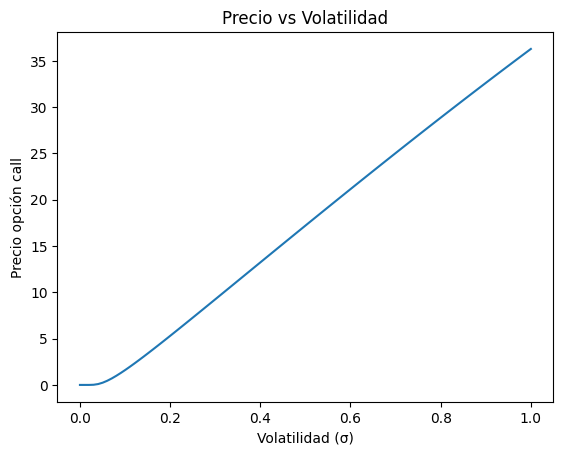

In [135]:
sigmas = np.linspace(0.0001, 1, 100)

prices = []

for s in sigmas:
    bs = black_scholes(Spot, K, mat, r, s)
    prices.append(bs['call'])  # o put

plt.plot(sigmas, prices)
plt.xlabel("Volatilidad (σ)")
plt.ylabel("Precio opción call")
plt.title("Precio vs Volatilidad")
plt.show()

BS(σ) es creciente en σ (lo cual significa que su derivada, o sea vega, es mayor a 0). Esto demuestra qye la solución para implied volatility, si existe, es única. Ésta solucion existe siempre y cuando no haya oportunidad de arbitraje.


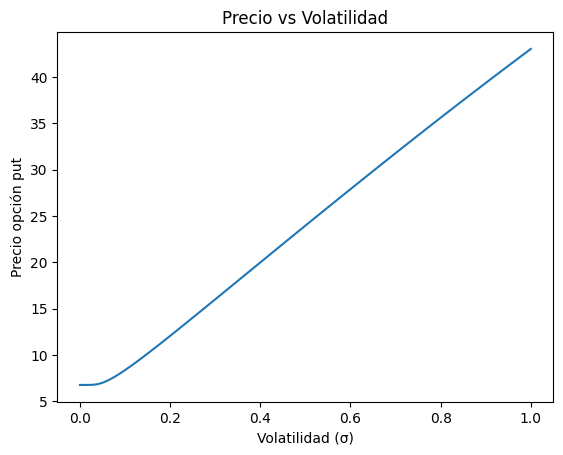

In [136]:
sigmas = np.linspace(0.0001, 1, 100)

prices = []

for s in sigmas:
    bs = black_scholes(Spot, K, mat, r, s)
    prices.append(bs['put'])

plt.plot(sigmas, prices)
plt.xlabel("Volatilidad (σ)")
plt.ylabel("Precio opción put")
plt.title("Precio vs Volatilidad")
plt.show()

Volatility smile

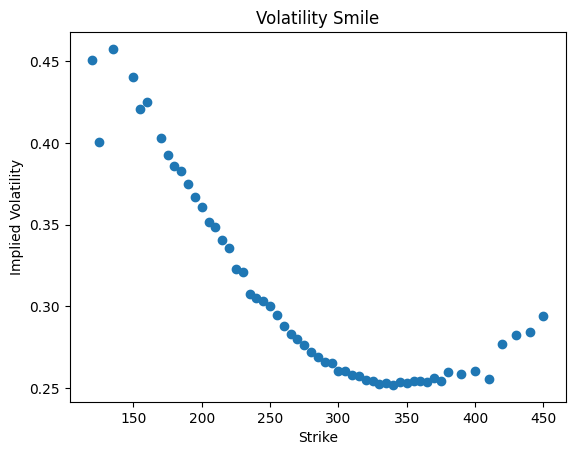

In [144]:
#calls
calls_mercado = []
calls_mercado = datos_mercado[datos_mercado["type"] == "call"].copy()
T_mat = calls_mercado["T"].median()

df_smile = calls_mercado[
    (calls_mercado["T"] > T_mat - 0.05) &
    (calls_mercado["T"] < T_mat + 0.05)
]

df_smile = df_smile.dropna(subset=["impvol_2"])

plt.scatter(df_smile["strike"], df_smile["impvol_2"])
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.show()

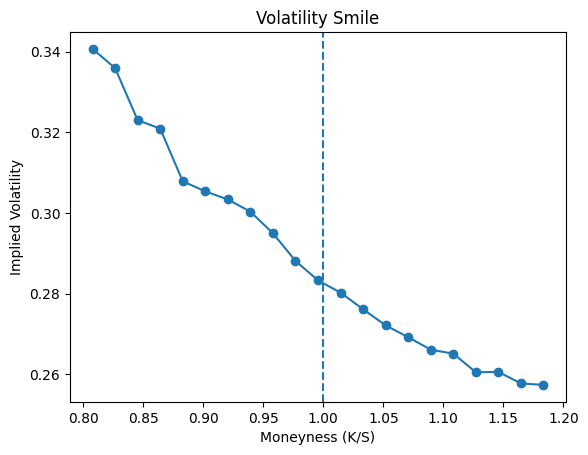

In [159]:
df_smile = df_smile.copy()

df_smile["moneyness"] = df_smile["strike"] / df_smile["spot"]
df_smile = df_smile[
    (df_smile["moneyness"] > 0.8) &
    (df_smile["moneyness"] < 1.2)
]
df_smile = df_smile.sort_values("moneyness")

plt.plot(df_smile["moneyness"], df_smile["impvol_2"], marker='o')
plt.xlabel("Moneyness (K/S)")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.axvline(1, linestyle='--')  # ATM
plt.show()

Aplicación - valuar una opción nueva

In [157]:
Strike_new = 100
Ttm_new = 2
Spot_new = Spot_mercado

#Aproximar volatilidad de acuerdo a lo que se ha calculado anteriormente
from scipy.interpolate import griddata
#calls
newdf = datos_mercado.copy()
newdf = newdf.dropna(subset=["impvol_2"])
newdf = newdf[newdf["type"] == "call"]

points = newdf[["strike", "T"]].values
values = newdf["impvol_2"].values

sigma_new_call = griddata(
    points,
    values,
    (Strike_new, Ttm_new),
    method="linear"
)

newdf = datos_mercado.copy()
newdf = newdf.dropna(subset=["impvol_2"])
newdf = newdf[newdf["type"] == "put"]

points = newdf[["strike", "T"]].values
values = newdf["impvol_2"].values

sigma_new_put = griddata(
    points,
    values,
    (Strike_new, Ttm_new),
    method="linear"
)

#Obtener r
r_new = tasa_libre(Ttm_new)

#Calcular precio
precio_call_new = black_scholes(Spot_new,Strike_new,Ttm_new,r_new,sigma_new_call)['call']
precio_put_new = black_scholes(Spot_new,Strike_new,Ttm_new,r_new,sigma_new_put)['put']
if sigma_new_call <= 0 or np.isnan(sigma_new_call):
    print("Warning: sigma call inválida")
else: print("Precio call:",precio_call_new)

if sigma_new_put <= 0 or np.isnan(sigma_new_put):
    print("Warning: sigma put inválida")
else: print("Precio put:", precio_put_new)


Precio call: 173.90414400404615
Precio put: 1.5488642609480072
